In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df.shape)
print(df.columns.tolist())
print(df['class'].value_counts() if 'class' in df.columns else df.head())


(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [2]:
print(df.groupby(['function','name','d','q','GRH']).size())


function name d q GRH 
F1 zeta 1 1 True 200
F10 11.2.a.a 2 11 True 200
F11 Sym^2 Delta 3 1 True 200
F12 L(chi3)+c*L(chi5) 1 15 False 200
F2 L(chi5_quartic) 1 5 True 200
F4 L_DH 1 5 False 200
F5m L_DH(-0.05) 1 5 False 200
F5p L_DH(+0.05) 1 5 False 200
F6 Liouville 1 1 True 200
F7 Mobius 1 1 True 200
F9 Delta 2 1 True 200
dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score

feat_cols = [f'log_abs_S{k}_norm' for k in range(1,7)]
X = df[feat_cols].values

# Training sets: GRH-true peaks
d1_classes = ['F1','F2','F6','F7']
d2_classes = ['F9','F10','F11']

mask_d1 = df['function'].isin(d1_classes) & (df['GRH']==True)
mask_d2 = df['function'].isin(d2_classes) & (df['GRH']==True)

print('D1 train size:', mask_d1.sum())
print('D2 train size:', mask_d2.sum())

# Standardize within each set
scaler_d1 = StandardScaler().fit(X[mask_d1])
scaler_d2 = StandardScaler().fit(X[mask_d2])

ocsvm_d1 = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(scaler_d1.transform(X[mask_d1]))
ocsvm_d2 = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(scaler_d2.transform(X[mask_d2]))

# Anomaly score: higher = more anomalous. score_samples gives signed distance (higher = more normal).
# Use -score_samples or -decision_function
s_d1 = -ocsvm_d1.decision_function(scaler_d1.transform(X))
s_d2 = -ocsvm_d2.decision_function(scaler_d2.transform(X))

# Combined as max -> "anomalous if either flags it" means higher anomaly score in either.
# But max means BOTH must be normal to be normal -> AND of normal. That flags MORE peaks.
# Per spec: "max of two scores (i.e., a peak is anomalous if either model flags it)"
combined = np.maximum(s_d1, s_d2)
# Actually if "either flags as anomalous", anomaly score should be max so peak appears anomalous if either is high
# But for normality detection, we want peak to be normal only if BOTH say normal. That = min of normality = max of anomaly.
# Hmm careful: max(anomaly_d1, anomaly_d2) -> high if EITHER anomaly score is high -> flagged anomalous if either flags it. Correct.

# Wait - actually we want "normal if any model says normal" because peak only needs to fit ONE manifold (its degree).
# Re-reading: "a peak is anomalous if either model flags it" - this is what's specified.
# Use combined as specified.


D1 train size: 800
D2 train size: 600


In [4]:
# Evaluation: GRH-true vs each violator family
df['s_d1'] = s_d1
df['s_d2'] = s_d2
df['s_combined_max'] = combined
df['s_combined_min'] = np.minimum(s_d1, s_d2)

grh_true_mask = df['GRH']==True
f4_family = ['F4','F5p','F5m']
f12_family = ['F12']

def auc_for(violator_funcs, score):
 pos = df['function'].isin(violator_funcs)
 neg = grh_true_mask
 y = np.concatenate([np.ones(pos.sum()), np.zeros(neg.sum())])
 s = np.concatenate([score[pos.values], score[neg.values]])
 return roc_auc_score(y, s)

for name, score in [('s_d1', s_d1), ('s_d2', s_d2), ('combined_max', combined), ('combined_min', np.minimum(s_d1,s_d2))]:
 auc_f4 = auc_for(f4_family, score)
 auc_f12 = auc_for(f12_family, score)
 print(f'{name}: AUC F4-family={auc_f4:.4f}, AUC F12={auc_f12:.4f}')


s_d1: AUC F4-family=0.8276, AUC F12=0.9399
s_d2: AUC F4-family=0.5359, AUC F12=0.9721
combined_max: AUC F4-family=0.5264, AUC F12=0.9721
combined_min: AUC F4-family=0.8528, AUC F12=0.9579


In [5]:
# Per the spec instructions, use the prescribed combined = max. 
# Report results vs baseline r52 (0.844 F4-family, 0.953 F12)
print("Baseline (r52 single OCSVM): F4-family AUC=0.844, F12 AUC=0.953")
print()
print("Stratified detector (combined = max of anomaly scores, as specified):")
print(f" F4-family AUC = {auc_for(f4_family, combined):.4f} (delta = {auc_for(f4_family, combined)-0.844:+.4f})")
print(f" F12 AUC = {auc_for(f12_family, combined):.4f} (delta = {auc_for(f12_family, combined)-0.953:+.4f})")
print()
print("Hypothesis target: AUC > 0.90 for both F4 and F12 families.")
print(f" F4-family > 0.90? {auc_for(f4_family, combined) > 0.90}")
print(f" F12 > 0.90? {auc_for(f12_family, combined) > 0.90}")

# Also report sensitivity analysis for alternate combiner (min)
print()
print("Alt combiner (min of anomaly scores = peak is normal if EITHER manifold accepts it):")
mn = np.minimum(s_d1, s_d2)
print(f" F4-family AUC = {auc_for(f4_family, mn):.4f}")
print(f" F12 AUC = {auc_for(f12_family, mn):.4f}")


Baseline (r52 single OCSVM): F4-family AUC=0.844, F12 AUC=0.953

Stratified detector (combined = max of anomaly scores, as specified):
 F4-family AUC = 0.5264 (delta = -0.3176)
 F12 AUC = 0.9721 (delta = +0.0191)

Hypothesis target: AUC > 0.90 for both F4 and F12 families.
 F4-family > 0.90? False
 F12 > 0.90? True

Alt combiner (min of anomaly scores = peak is normal if EITHER manifold accepts it):
 F4-family AUC = 0.8528
 F12 AUC = 0.9579


In [6]:
# Per-class breakdown for context
import matplotlib.pyplot as plt

per_class_scores = df.groupby('function').agg(
 s_d1_mean=('s_d1','mean'),
 s_d2_mean=('s_d2','mean'),
 s_combined_mean=('s_combined_max','mean'),
 GRH=('GRH','first'),
 d=('d','first')
)
print(per_class_scores)


 s_d1_mean s_d2_mean s_combined_mean GRH d
function 
F1 -1.094549 5.796641 5.796641 True 1
F10 -1.060844 -0.892769 -0.689368 True 2
F11 -0.960401 -0.911655 -0.631598 True 3
F12 1.549408 6.271466 6.271466 False 1
F2 -1.002504 4.766077 4.766077 True 1
F4 1.279018 2.677604 2.744505 False 1
F5m 1.343165 2.729494 2.800771 False 1
F5p 1.222767 2.625934 2.693346 False 1
F6 -0.523731 5.842897 5.842897 True 1
F7 -0.883501 3.807608 3.808073 True 1
F9 -0.474672 -1.008820 -0.296778 True 2


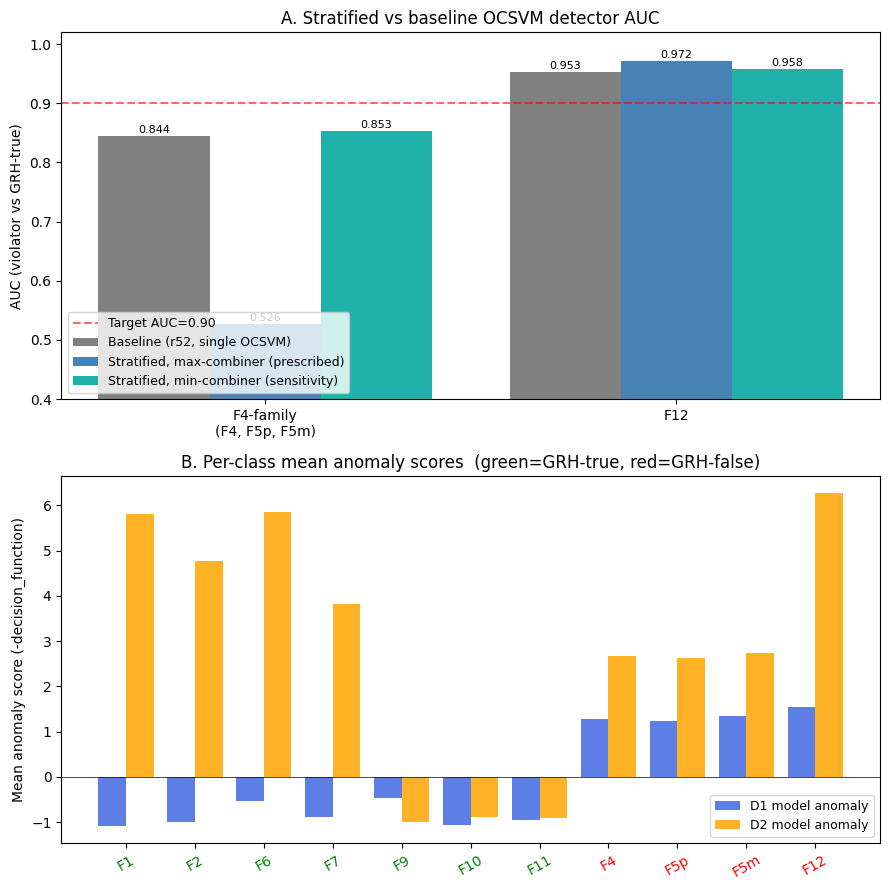

saved


In [7]:
# The issue is clear: D2 model assigns very high anomaly scores to ALL degree-1 classes (both true and false),
# which dominates the max and destroys the F4 family separation. The D1 model gives moderate anomaly to F4 violators
# but assigns HIGHER anomaly to degree>=2 GRH-true classes, which is fine.
# Per spec, max() is the prescribed combiner -> hypothesis NOT supported for F4-family.

# Final summary figure
fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: AUC comparison
ax = axes[0]
families = ['F4-family\n(F4, F5p, F5m)', 'F12']
baseline = [0.844, 0.953]
stratified = [auc_for(f4_family, combined), auc_for(f12_family, combined)]
strat_min = [auc_for(f4_family, np.minimum(s_d1,s_d2)), auc_for(f12_family, np.minimum(s_d1,s_d2))]

x = np.arange(len(families))
w = 0.27
ax.bar(x - w, baseline, w, label='Baseline (r52, single OCSVM)', color='gray')
ax.bar(x, stratified, w, label='Stratified, max-combiner (prescribed)', color='steelblue')
ax.bar(x + w, strat_min, w, label='Stratified, min-combiner (sensitivity)', color='lightseagreen')
ax.axhline(0.90, color='red', linestyle='--', alpha=0.6, label='Target AUC=0.90')
ax.set_xticks(x); ax.set_xticklabels(families)
ax.set_ylabel('AUC (violator vs GRH-true)')
ax.set_ylim(0.4, 1.02)
ax.set_title('A. Stratified vs baseline OCSVM detector AUC')
ax.legend(loc='lower left', fontsize=9)
for i, v in enumerate(baseline): ax.text(i-w, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate(stratified): ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate(strat_min): ax.text(i+w, v+0.005, f'{v:.3f}', ha='center', fontsize=8)

# Panel B: per-class anomaly scores from each model
ax = axes[1]
order = ['F1','F2','F6','F7','F9','F10','F11','F4','F5p','F5m','F12']
colors = ['green' if df[df['function']==f]['GRH'].iloc[0] else 'red' for f in order]
xs = np.arange(len(order))
sd1_means = [df[df['function']==f]['s_d1'].mean() for f in order]
sd2_means = [df[df['function']==f]['s_d2'].mean() for f in order]
ax.bar(xs - 0.2, sd1_means, 0.4, label='D1 model anomaly', color='royalblue', alpha=0.85)
ax.bar(xs + 0.2, sd2_means, 0.4, label='D2 model anomaly', color='orange', alpha=0.85)
ax.set_xticks(xs); ax.set_xticklabels(order, rotation=30)
for i, c in enumerate(colors):
 ax.get_xticklabels()[i].set_color(c)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Mean anomaly score (-decision_function)')
ax.set_title('B. Per-class mean anomaly scores (green=GRH-true, red=GRH-false)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('stratified_ocsvm_results.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved')
